In [1]:
import pandas as pd
d=pd.read_csv(r"C:\Users\91945\OneDrive\Desktop\time series\sales.csv")
d.head()

,Date,Amount
0,1/1/2000,510
1,2/1/2000,515
2,3/1/2000,530
3,4/1/2000,527
4,5/1/2000,519


In [2]:
d.tail()

,Date,Amount
103,8/1/2008,766
104,9/1/2008,703
105,10/1/2008,644
106,11/1/2008,604
107,12/1/2008,630


In [3]:
d["Date"]=pd.to_datetime(d["Date"])
d.tail()

,Date,Amount
103,2008-08-01,766
104,2008-09-01,703
105,2008-10-01,644
106,2008-11-01,604
107,2008-12-01,630


In [4]:
d.set_index("Date",inplace=True)
d.head()

,Amount
Date,
2000-01-01,510
2000-02-01,515
2000-03-01,530
2000-04-01,527
2000-05-01,519


<Axes: xlabel='Date'>

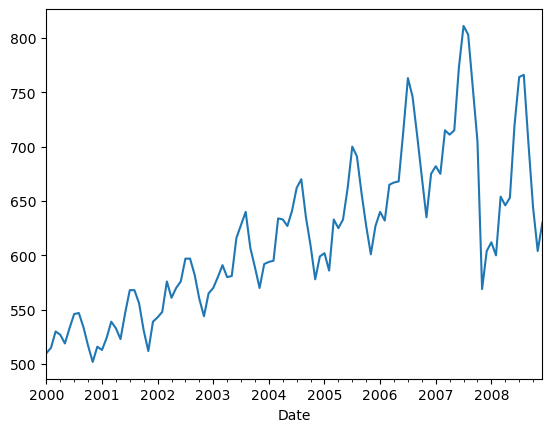

In [5]:
d["Amount"].plot()

In [6]:
from statsmodels.tsa.stattools import adfuller 
def adf_test(data):
    res=adfuller(data)
    print("p_value :",res[1])
    if res[1]<=0.05:
        print("Reject hypothesis null, Data is stationary ")
    else:
         print("Accept hypothesis null, Data is not stationary ")

In [7]:
adf_test(d["Amount"])

p_value : 0.5644352099925041
Accept hypothesis null, Data is not stationary 


In [8]:
d["1st_diff"]=d["Amount"]-d["Amount"].shift(1)
d

,Amount,1st_diff
Date,,
2000-01-01,510,NaN
2000-02-01,515,5.0
2000-03-01,530,15.0
2000-04-01,527,-3.0
2000-05-01,519,-8.0
...,...,...
2008-08-01,766,2.0
2008-09-01,703,-63.0
2008-10-01,644,-59.0


In [13]:
adf_test(d["1st_diff"].dropna())

p_value : 0.07478507605167095
Accept hypothesis null, Data is not stationary 


In [ ]:

d["2nd_diff"]=d["1st_diff"]-d["1st_diff"].shift(1)

,Amount,1st_diff,2nd_diff
Date,,,
2000-01-01,510,NaN,NaN
2000-02-01,515,5.0,NaN
2000-03-01,530,15.0,10.0
2000-04-01,527,-3.0,-18.0
2000-05-01,519,-8.0,-5.0
...,...,...,...
2008-08-01,766,2.0,-42.0
2008-09-01,703,-63.0,-65.0
2008-10-01,644,-59.0,4.0


In [13]:
adf_test(d["2nd_diff"].dropna())

p_value : 3.4877399176947928e-15
Reject hypothesis null, Data is stationary 


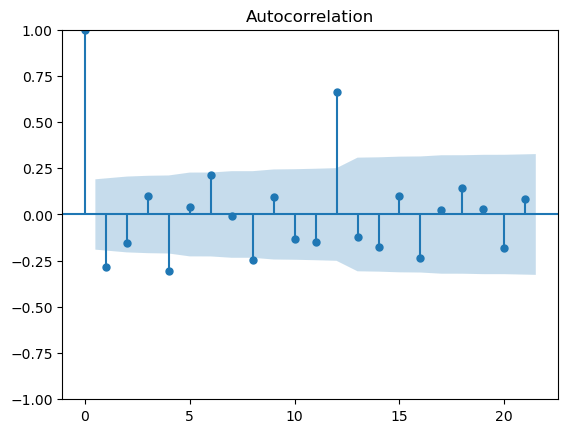

In [14]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
p1=plot_acf(d["2nd_diff"].dropna())

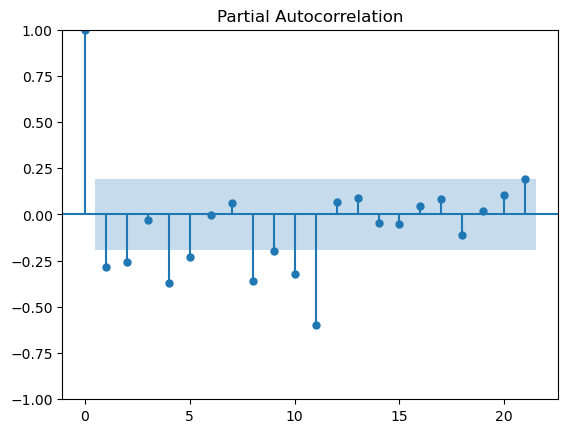

In [15]:
p2=plot_pacf(d["2nd_diff"].dropna())

In [16]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime
train_data=d
train_data

,Amount,1st_diff,2nd_diff
Date,,,
2000-01-01,510,NaN,NaN
2000-02-01,515,5.0,NaN
2000-03-01,530,15.0,10.0
2000-04-01,527,-3.0,-18.0
2000-05-01,519,-8.0,-5.0
...,...,...,...
2008-08-01,766,2.0,-42.0
2008-09-01,703,-63.0,-65.0
2008-10-01,644,-59.0,4.0


In [17]:
m=ARIMA(train_data["Amount"],order=(17,2,3))
model=m.fit()

C:\Users\91945\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\91945\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\91945\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\91945\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\91945\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA param

In [19]:
pred=model.predict(start=datetime(2003,1,1),end=datetime(2008,12,1))

In [20]:
train_data["predict"]=pred
train_data

,Amount,1st_diff,2nd_diff,predict
Date,,,,
2000-01-01,510,NaN,NaN,NaN
2000-02-01,515,5.0,NaN,NaN
2000-03-01,530,15.0,10.0,NaN
2000-04-01,527,-3.0,-18.0,NaN
2000-05-01,519,-8.0,-5.0,NaN
...,...,...,...,...
2008-08-01,766,2.0,-42.0,760.075786
2008-09-01,703,-63.0,-65.0,736.168305
2008-10-01,644,-59.0,4.0,649.998833


<Axes: xlabel='Date'>

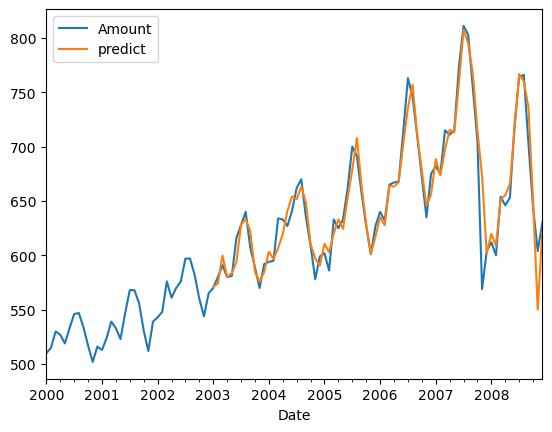

In [21]:
train_data[["Amount","predict"]].plot()

<Axes: xlabel='Date'>

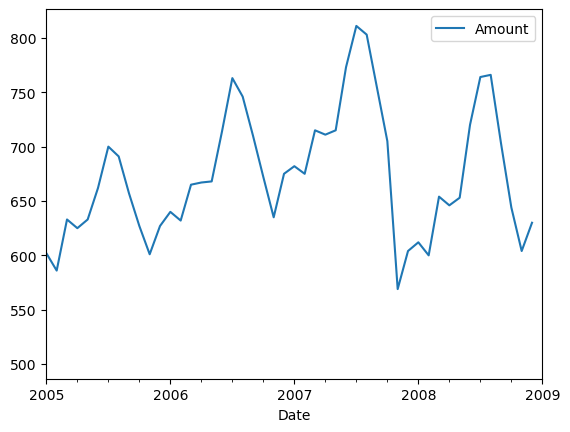

In [22]:
pred1=model.predict(start=datetime(2009,1,1),end=datetime(2009,12,1))
train_data["future_pred"]=pred1
train_data[["Amount"]].plot(xlim=["2005-01-01","2009-01-01"])


<Axes: >

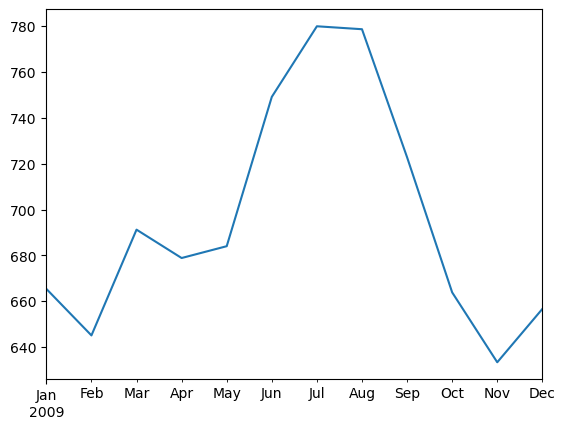

In [ ]:
pred1.plot()

In [24]:
import pickle
with open("arima_model.pkl", "wb") as f:
    pickle.dump(model, f)